# 02 - Filtros e features

Carrega o dump bruto, aplica os filtros do paper (`delta_G in [-2,2]`, cobertura <= 25%, ligacao H-superficie em [1,3] A), calcula as 10 features e mostra as distribuicoes antes/depois.

Toda a logica vem de `src`

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from dataset import build_records
from features import FEATURE_NAMES
from ingest import load_raw_dump

logging.basicConfig(level=logging.WARNING)
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA = ROOT / "data"

In [2]:
nodes = load_raw_dump(DATA / "raw" / "catalysis_hub_dump.json")
print(f"reacoes brutas: {len(nodes)}")

records, stats = build_records(nodes)
pd.Series(dict(stats)).to_frame("count")

reacoes brutas: 9135



building records:   0%|          | 0/9135 [00:00<?, ?it/s]


building records:   0%|          | 1/9135 [00:00<1:14:58,  2.03it/s]


building records:   0%|          | 5/9135 [00:01<32:45,  4.64it/s]  


building records:   0%|          | 7/9135 [00:01<34:03,  4.47it/s]

...


building records:  99%|█████████▉| 9037/9135 [01:08<00:00, 116.34it/s]


building records:  99%|█████████▉| 9066/9135 [01:09<00:00, 135.19it/s]


building records: 100%|█████████▉| 9130/9135 [01:09<00:00, 204.77it/s]


building records: 100%|██████████| 9135/9135 [01:09<00:00, 132.00it/s]

,count
total,9135
kept,5860
no_features,185
no_structure,19
"reject:bond length 0.97 out of [1.0, 3.0]",12
duplicate,3059


## Distribuicao de delta_G_H: antes vs depois dos filtros

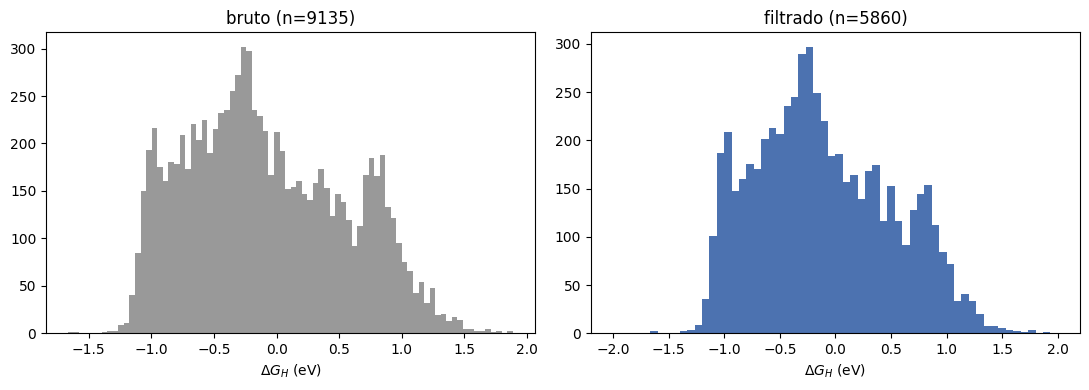

In [3]:
raw_dG = [n["reactionEnergy"] for n in nodes]
kept_dG = [r["delta_G_H"] for r in records]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(raw_dG, bins=80, color="0.6")
axes[0].set_title(f"bruto (n={len(raw_dG)})")
axes[0].set_xlabel(r"$\Delta G_H$ (eV)")
axes[1].hist(kept_dG, bins=60, range=(-2, 2), color="#4c72b0")
axes[1].set_title(f"filtrado (n={len(kept_dG)})")
axes[1].set_xlabel(r"$\Delta G_H$ (eV)")
plt.tight_layout()
plt.show()

## Tipos de sitio de adsorcao

hollow    3163
top       1585
bridge    1112
Name: count, dtype: int64


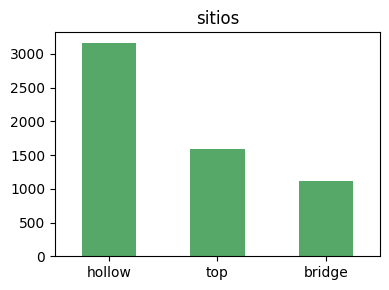

In [4]:
sites = pd.Series([r["site_type"] for r in records]).value_counts()
print(sites)
sites.plot.bar(color="#55a868", rot=0, figsize=(4, 3), title="sitios")
plt.tight_layout()
plt.show()

## Features: estatisticas e correlacao

In [5]:
feat_df = pd.DataFrame([r["features"] for r in records])
feat_df["delta_G_H"] = kept_dG
feat_df.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
phi,5860.0,166.630,140.272,0.000,52.632,122.500,303.161,500.000
L_bond,5860.0,1.857,0.169,1.102,1.743,1.854,1.961,2.400
Np0,5860.0,17.759,4.800,2.000,13.000,18.000,21.805,27.000
Nd1,5860.0,15.569,7.931,0.000,10.000,16.035,21.151,30.000
Out_e0,5860.0,6.788,2.843,3.000,4.000,6.767,9.000,12.000
R0,5860.0,144.412,14.291,70.000,135.000,140.000,152.971,195.000
First_IE0,5860.0,7.444,0.958,5.577,6.759,7.434,7.902,11.260
CN,5860.0,9.467,1.828,0.000,9.487,10.000,10.000,15.000
Out_e1,5860.0,6.710,2.605,3.000,4.373,6.503,8.963,12.000
psi1,5860.0,1.794,0.264,1.100,1.630,1.800,1.961,2.748


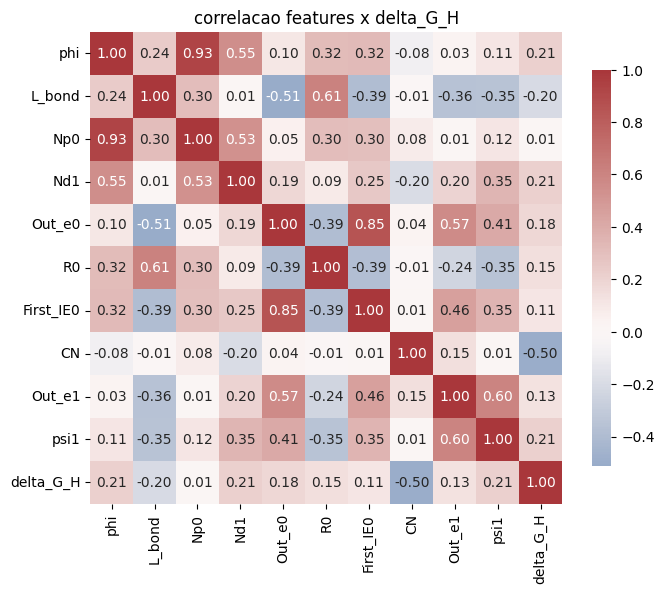

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    feat_df[[*FEATURE_NAMES, "delta_G_H"]].corr(),
    annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
    cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("correlacao features x delta_G_H")
plt.tight_layout()
plt.show()